## 인프라 확장성 분석
### 노선 수에 따른 편의시설 수 관계와 증가폭
“1개 노선역, 2개 노선역, 3개 노선역으로 갈수록 편의시설 수는 얼마나 증가하는가? 그리고 증가폭이 무임 이용 수요 증가폭을 따라가고 있는가?”

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import koreanize_matplotlib

from scipy.stats import mannwhitneyu

In [11]:
top_20_df = pd.read_csv("../../data/processed/team/top_20_df.csv")

In [12]:
# 노선 수별 비교
candidate_df = top_20_df.copy()

# 노선 수 계산
candidate_df['노선수'] = candidate_df['호선명'].astype(str).str.split(',').str.len()

# 1, 2, 3노선역만 보기
line_df = candidate_df[candidate_df['노선수'].isin([1, 2, 3])].copy()

# 요약표
q7_summary = line_df.groupby('노선수').agg(
    역수=('지하철역', 'count'),
    평균_편의시설수=('TOTAL', 'mean'),
    중앙값_편의시설수=('TOTAL', 'median'),
    평균_가중편의시설합=('가중편의시설합', 'mean'),
    중앙값_가중편의시설합=('가중편의시설합', 'median'),
    평균_무임승하차=('무임승하차', 'mean'),
    중앙값_무임승하차=('무임승하차', 'median'),
    평균_시설부하지수=('시설부하지수', 'mean'),
    중앙값_시설부하지수=('시설부하지수', 'median')
).round(2)

q7_summary

,역수,평균_편의시설수,중앙값_편의시설수,평균_가중편의시설합,중앙값_가중편의시설합,평균_무임승하차,중앙값_무임승하차,평균_시설부하지수,중앙값_시설부하지수
노선수,,,,,,,,,
1,40,7.05,7.0,15.52,14.5,305980.12,267049.0,20743.20,18502.75
2,8,16.25,15.5,31.62,32.0,510662.75,533243.0,16541.80,16106.91
3,1,27.00,27.0,48.00,48.0,903628.00,903628.0,18825.58,18825.58


In [13]:
# 증가율
increase_results = []

for before, after in [(1, 2), (2, 3)]:
    if before in q7_summary.index and after in q7_summary.index:
        increase_results.append({
            '비교구간': f'{before}노선 → {after}노선',
            '편의시설수_증가율(%)': round((q7_summary.loc[after, '평균_편의시설수'] / q7_summary.loc[before, '평균_편의시설수'] - 1) * 100, 2),
            '가중편의시설합_증가율(%)': round((q7_summary.loc[after, '평균_가중편의시설합'] / q7_summary.loc[before, '평균_가중편의시설합'] - 1) * 100, 2),
            '무임승하차_증가율(%)': round((q7_summary.loc[after, '평균_무임승하차'] / q7_summary.loc[before, '평균_무임승하차'] - 1) * 100, 2),
            '시설부하지수_증감률(%)': round((q7_summary.loc[after, '평균_시설부하지수'] / q7_summary.loc[before, '평균_시설부하지수'] - 1) * 100, 2)
        })

q7_increase_df = pd.DataFrame(increase_results)
q7_increase_df

,비교구간,편의시설수_증가율(%),가중편의시설합_증가율(%),무임승하차_증가율(%),시설부하지수_증감률(%)
0,1노선 → 2노선,130.50,103.74,66.89,-20.25
1,2노선 → 3노선,66.15,51.80,76.95,13.81


In [14]:
# 1노선 vs 2노선 검증
# 3노선역은 표본이 1개여서 통계 검증은 무리
one_line = line_df[line_df['노선수'] == 1]
two_line = line_df[line_df['노선수'] == 2]

q7_test_results = []
for col, label in [
    ('TOTAL', '편의시설수'),
    ('가중편의시설합', '가중편의시설합'),
    ('무임승하차', '무임승하차'),
    ('시설부하지수', '시설부하지수')
]:
    stat, p = mannwhitneyu(one_line[col], two_line[col], alternative='two-sided')
    q7_test_results.append({
        '지표': label,
        '1노선역_평균': round(one_line[col].mean(), 2),
        '2노선역_평균': round(two_line[col].mean(), 2),
        '1노선역_중앙값': round(one_line[col].median(), 2),
        '2노선역_중앙값': round(two_line[col].median(), 2),
        'p-value': round(p, 6)
    })

q7_test_df = pd.DataFrame(q7_test_results)
q7_test_df

,지표,1노선역_평균,2노선역_평균,1노선역_중앙값,2노선역_중앙값,p-value
0,편의시설수,7.05,16.25,7.00,15.50,0.000283
1,가중편의시설합,15.52,31.62,14.50,32.00,0.000057
2,무임승하차,305980.12,510662.75,267049.00,533243.00,0.000250
3,시설부하지수,20743.20,16541.80,18502.75,16106.91,0.222983


In [16]:
# 시각화 전 준비
line_df = top_20_df.copy()

# 노선 수 계산
line_df['노선수'] = line_df['호선명'].astype(str).str.split(',').str.len()

# 1, 2, 3노선역만 사용
line_df = line_df[line_df['노선수'].isin([1, 2, 3])].copy()

# 문자열 라벨 추가
line_df['노선구분'] = line_df['노선수'].astype(str) + '노선역'

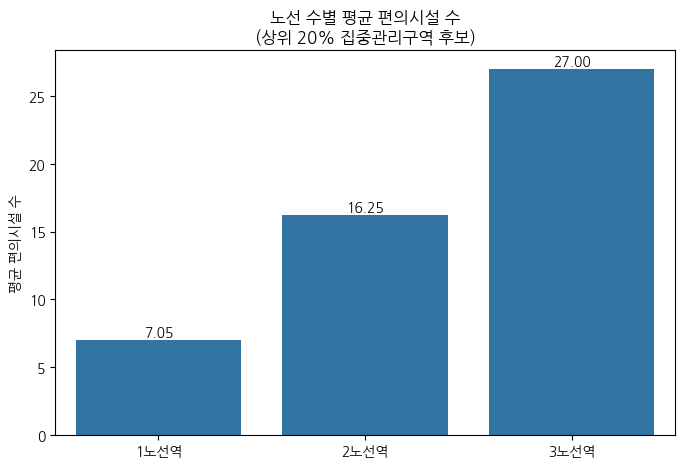

In [17]:
# 평균 편의시설 수 비교
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=line_df,
    x='노선구분',
    y='TOTAL',
    order=['1노선역', '2노선역', '3노선역'],
    estimator=np.mean,
    errorbar=None
)
plt.title('노선 수별 평균 편의시설 수\n(상위 20% 집중관리구역 후보)')
plt.xlabel('')
plt.ylabel('평균 편의시설 수')

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom', fontsize=10)

plt.show()

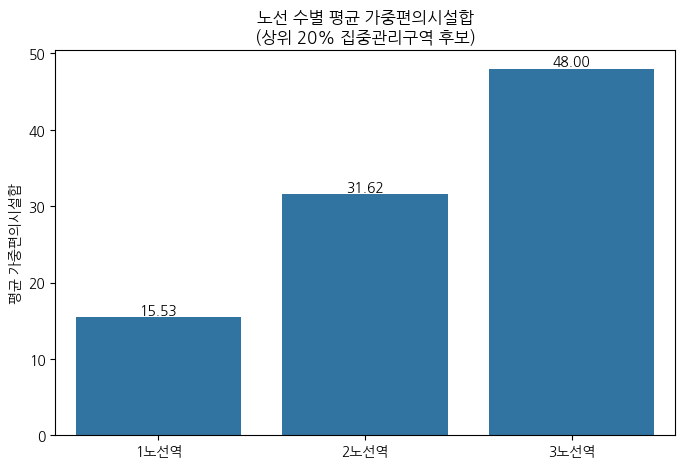

In [18]:
# 평균 가중편의시설합 비교
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=line_df,
    x='노선구분',
    y='가중편의시설합',
    order=['1노선역', '2노선역', '3노선역'],
    estimator=np.mean,
    errorbar=None
)
plt.title('노선 수별 평균 가중편의시설합\n(상위 20% 집중관리구역 후보)')
plt.xlabel('')
plt.ylabel('평균 가중편의시설합')

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom', fontsize=10)

plt.show()


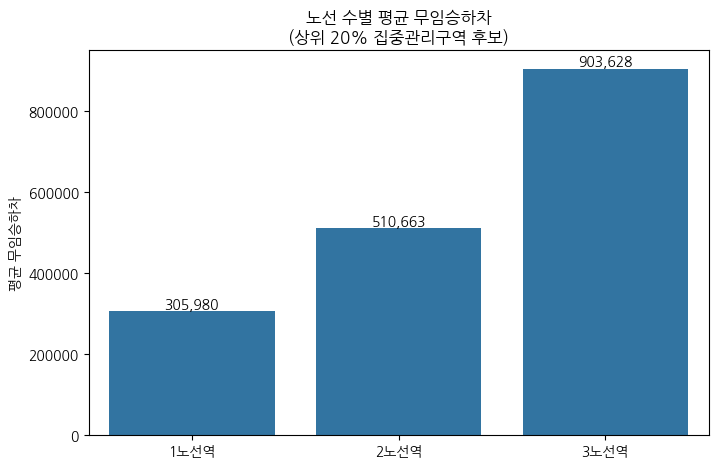

In [19]:
# 평균 무임승하차 비교
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=line_df,
    x='노선구분',
    y='무임승하차',
    order=['1노선역', '2노선역', '3노선역'],
    estimator=np.mean,
    errorbar=None
)
plt.title('노선 수별 평균 무임승하차\n(상위 20% 집중관리구역 후보)')
plt.xlabel('')
plt.ylabel('평균 무임승하차')

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:,.0f}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom', fontsize=10)

plt.show()

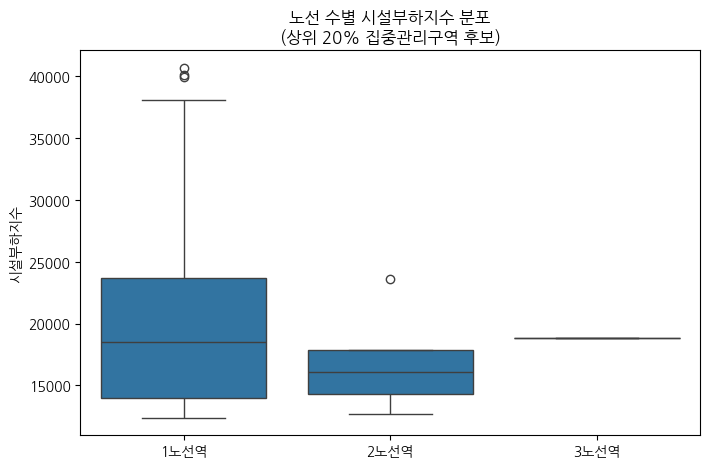

In [20]:
# 시설부하지수 분포 비교
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=line_df,
    x='노선구분',
    y='시설부하지수',
    order=['1노선역', '2노선역', '3노선역']
)
plt.title('노선 수별 시설부하지수 분포\n(상위 20% 집중관리구역 후보)')
plt.xlabel('')
plt.ylabel('시설부하지수')
plt.show()